<h1 style="text-align: center; color: darkblue;">Report</h1>

### 📑 <font color='blue'> Table of Contents </font>
1. [Introduction](#1)
2. [Setup](#2)
3. [Helper Functions](#3)
4. [Best Model Summary](#4)
5. [Results on Test set](#5)
6. [Conclusions](#6)

## <a id="1" style="color: darkred; text-decoration: none;">1. Introduction</a>

This notebook presents the results of the project.

We first summarize the training configuration and validation performance of the selected model, including its key parameters and metrics.
Next, we assess its generalization ability on the test set, reporting the main classification metrics — accuracy, precision, recall, and F1-score — along with the ROC curves and confusion matrix to provide a more detailed view of the model’s behavior across classes.

## <a id="2" style="color: darkred; text-decoration: none;">2. Setup</a>

In [1]:
import pandas as pd
import mlflow
import matplotlib.pyplot as plt
from PIL import Image
import os

from mlflow.tracking import MlflowClient

from pathlib import Path

In [2]:
mlflow_path = Path().resolve().parent / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{mlflow_path}")

In [3]:
# ANSI codes
BOLD = "\033[1m"
CYAN = "\033[36m"
RESET = "\033[0m"
ORANGE = "\033[38;5;208m"

## <a id="3" style="color: darkred; text-decoration: none;">3. Helper Functions </a>

In [4]:
# best model (according to f1)
def select_best_model(experiment_name, metric="f1", model_type=None, data_version="v1"):
    client = MlflowClient()
    experiment = client.get_experiment_by_name(experiment_name)
    if experiment is None:
        raise ValueError(f"Experiment '{experiment_name}' not found.")

    # Build filter
    filter_str = f"run_name = 'Tuning' AND tags.data_version = '{data_version}'"
    if model_type:
        filter_str += f" AND tags.model_type = '{model_type}'"

    # Search runs
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=filter_str,
        order_by=[f"metrics.{metric} DESC"],
    )

    if not runs:
        raise ValueError(f"No runs found for model_type='{model_type}' and data_version='{data_version}'.")

    # Return best run
    return runs[0]

In [5]:
# get test_data
def get_test_data(experiment_name, tuning_run_id, data_version="v1"):
    client = MlflowClient()
    experiment = client.get_experiment_by_name(experiment_name)
    
    if experiment is None:
        raise ValueError(f"Experiment '{experiment_name}' not found.")

    # Build filter
    filter_str = f"run_name = 'test_evaluation' AND tags.data_version = '{data_version}'"
    filter_str += f" AND tags.tuning_run_id = '{tuning_run_id}'"

    # Search runs
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=filter_str,
    )

    if not runs:
        raise ValueError(f"No runs found")

    # return
    return runs[0]

In [6]:
# Plotting
def plot_curve(path, figsize=(10, 8)):
    img_cm = Image.open(path)
    plt.figure(figsize=figsize)
    plt.imshow(img_cm)
    plt.axis("off")
    plt.show()


## <a id="4" style="color: darkred; text-decoration: none;">4. Best Model Summary </a>

In [8]:
run = select_best_model("network_security")


# Get metrics and params
metrics = run.data.metrics
params = run.data.params


# Converto to dataframe
df_params = pd.DataFrame({
    "param": list(params.keys()),
    "value": list(params.values())
})


df = pd.DataFrame({
    "metric": list(metrics.keys()),
    "value": list(metrics.values())
})

In [9]:
print(f"\n{BOLD}{ORANGE}PARAMETERS\n----------{RESET}\n")

print(f"{BOLD}Model type{RESET}: {run.data.tags['model_type']}\n")

df_params


PARAMETERS
----------

Model type: tree



,param,value
0,balance_factor,0.2
1,val_size,0.1
2,train_shape,"(169235, 78)"
3,val_shape,"(7731, 78)"
4,criterion,entropy
5,max_depth,16
6,min_samples_split,8


In [10]:
print(f"\n{BOLD}{ORANGE}METRICS\n-------{RESET}\n")

df


METRICS
-------



,metric,value
0,accuracy,0.997413
1,precision,0.997471
2,recall,0.997413
3,f1,0.997435


The model performs **almost perfectly** on the validation set. All metrics—accuracy, precision, recall, and F1—are around **0.997**, indicating it correctly identifies virtually all samples with almost no false positives or false negatives. This is extremely strong and well-balanced performance.

## <a id="5" style="color: darkred; text-decoration: none;">5. Results on test set </a>

In [11]:
r = get_test_data('network_security', run.info.run_id)

In [12]:
print(f"\n{BOLD}{ORANGE}METRICS ON THE TEST SET\n-----------------------{RESET}\n")

metrics_test = r.data.metrics

# Converto to dataframe
df_metrics_test = pd.DataFrame({
    "param": list(metrics_test.keys()),
    "value": list(metrics_test.values())
})


df_metrics_test


METRICS ON THE TEST SET
-----------------------



,param,value
0,accuracy,0.998101
1,precision,0.998106
2,recall,0.998101
3,f1,0.998101


The test set performance is **even slightly better** than the validation set, with all metrics around **0.9981**. This shows the model generalizes extremely well and is not overfitting—its behavior is consistent and highly accurate on unseen data.

**Plots**

In [13]:
artifact_uri = run.info.artifact_uri
print(artifact_uri)

/home/marcos/Escritorio/AI-prod/AI-Driven-Network-Security/mlruns/1/9699918508f84749b1fdf6f873e09d8e/artifacts


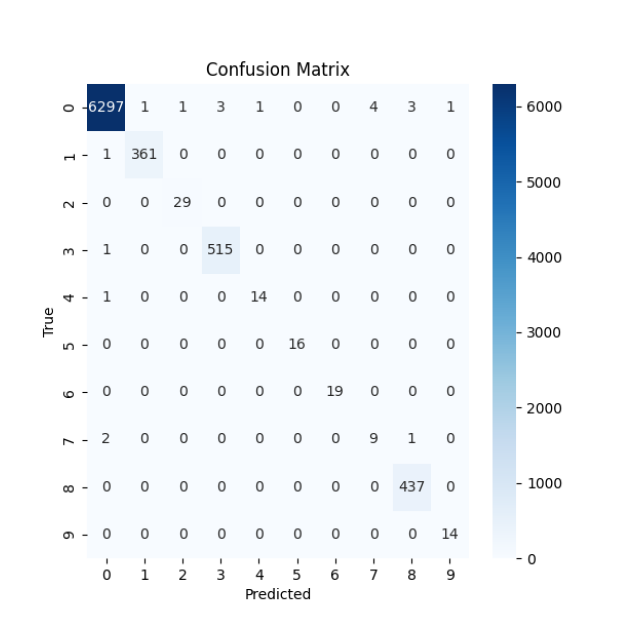

In [14]:
cm_path = os.path.join(artifact_uri, "confusion_matrix.png")

plot_curve(cm_path, figsize=(10, 8))

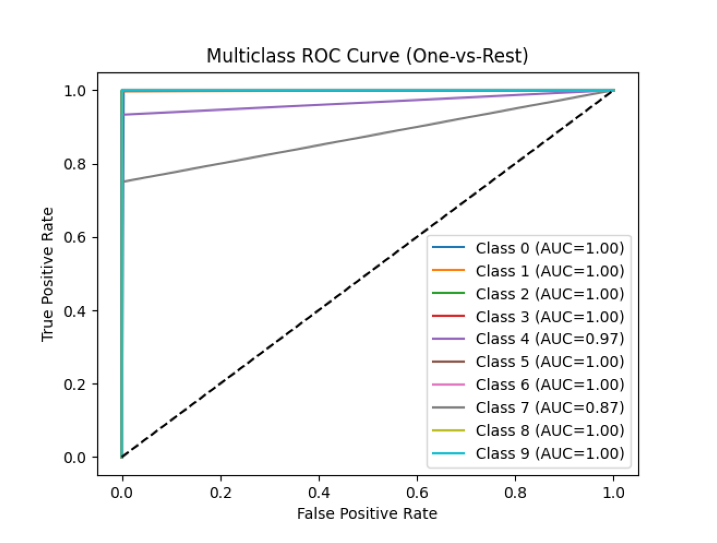

In [15]:
roc_path = os.path.join(artifact_uri, "roc_multiclass.png")

plot_curve(roc_path, (9,7))


## <a id="6" style="color: darkred; text-decoration: none;">6. Conclusions </a>

The model achieves extremely high and consistent performance on both validation and test sets (≈0.998), indicating excellent generalization. However, these results should be interpreted with caution, since the ICS dataset is not particularly difficult—so such high scores are expected for this type of problem.
